In [2]:
import json
import os
import urllib

import folium
import geemap.foliumap as geemap
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import rasterio
import requests
import rioxarray
import seaborn
import xarray as xr
from geotessera import GeoTessera
from helpers.simplecube import load_xarray, save_xarray, simple_cube
from helpers.simplecube_helpers import *
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import Affine
from scipy.signal import savgol_filter
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

STAC_URL = "https://data.inpe.br/bdc/stac/v1"
WTSS_URL = "https://data.inpe.br/bdc/wtss/v4/"

test_tile_path = "./dataset/test_tile/"
roi_tile_path = "./dataset/roi_tiles/"

output_dir = "./dataset/rasters"
os.makedirs(output_dir, exist_ok = True)

cube_id = "S2-16D-2"
year = 2024

service = pystac_client.Client.open(STAC_URL)
collection = service.get_collection(cube_id).to_dict()
bands_description = collection['properties']['eo:bands']
start, end = (f"{year}-01-01", f"{year}-12-31")
composition = get_composition(cube_id, reject = ["thumbnail", "CMASK", "CLEAROB", "TOTALOB", "DATASOURCE", "PROVENANCE", "SCL"])

## Test Tile

-61.25000000000001,-8.25,-61.0,-7.999999999999998


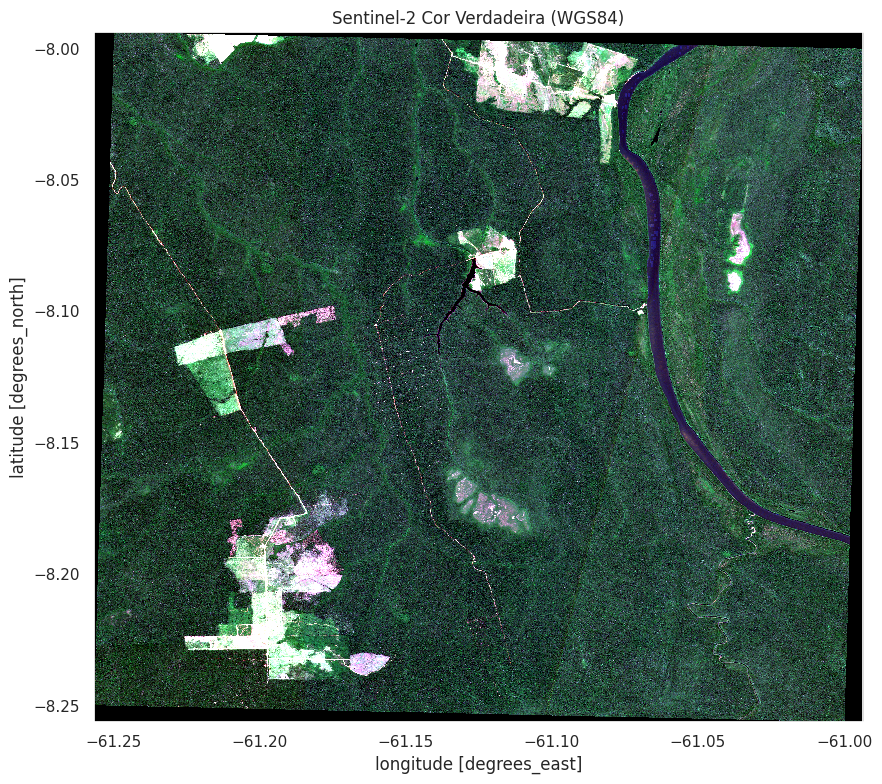

In [28]:
test_tile_name = "tile_C51L41_WGS84"
test_tile = gpd.read_file(f"{test_tile_path}{test_tile_name}.gpkg")
if test_tile.crs != "EPSG:4326":
    test_tile = test_tile.to_crs(epsg=4326)
test_tile_id = test_tile.iloc[0]["id"]
bbox_test = list([ float(b) for b in test_tile.total_bounds ])
bbox_test = format_bbox(bbox_test)
print(bbox_test)

# cube = simple_cube(
#      stac_url   = STAC_URL,
#      collection = cube_id,
#      start_date = start,
#      end_date   = end,
#      bbox       = bbox,
#      bands      = composition
# )
# save_xarray(cube, f'{output_dir}/cube_sentinel2_{year}_{test_tile_id}.nc')

time_idx = 10
tile = test_tile
tile_id = tile.iloc[0]["id"]
bbox = list([ float(b) for b in tile.total_bounds ])
cube = load_xarray(f'{output_dir}/cube_sentinel2_{year}_{tile_id}.nc')
cube_ = cube.isel(time=time_idx)
cube_ = cube_.rio.reproject(WGS84_WKT)
cube_ = normalize_rgb(cube_)

plot_xarray_(
    cube_,
    bands=["red", "green", "blue"],
    title="Sentinel-2 Cor Verdadeira (WGS84)",
)

## Region of Interest

In [4]:
roi_1_tile_name = "tile_C51L34_Eco03_WGS84"
roi_1_tile = gpd.read_file(f"{roi_tile_path}{roi_1_tile_name}.gpkg")
if roi_1_tile.crs != "EPSG:4326":
    roi_1_tile = roi_1_tile.to_crs(epsg=4326)
roi_1_tile_id = roi_1_tile.iloc[0]["id"]
bbox_roi_1 = list([ float(b) for b in roi_1_tile.total_bounds ])
bbox_roi_1 = format_bbox(bbox_roi_1)
print(bbox_roi_1)

# cube = simple_cube(
#      stac_url   = STAC_URL,
#      collection = cube_id,
#      start_date = start,
#      end_date   = end,
#      bbox       = bbox_roi_1,
#      bands      = composition
# )
# save_xarray(cube, f'{output_dir}/cube_sentinel2_{year}_{roi_1_tile_id}.nc')

roi_2_tile_name = "tile_C60L63_Eco01_WGS84"
roi_2_tile = gpd.read_file(f"{roi_tile_path}{roi_2_tile_name}.gpkg")
if roi_2_tile.crs != "EPSG:4326":
    roi_2_tile = roi_2_tile.to_crs(epsg=4326)
roi_2_tile_id = roi_2_tile.iloc[0]["id"]
bbox_roi_2 = list([ float(b) for b in roi_2_tile.total_bounds ])
bbox_roi_2 = format_bbox(bbox_roi_2)
print(bbox_roi_2)

# cube = simple_cube(
#      stac_url   = STAC_URL,
#      collection = cube_id,
#      start_date = start,
#      end_date   = end,
#      bbox       = bbox_roi_2,
#      bands      = composition
# )
# save_xarray(cube, f'{output_dir}/cube_sentinel2_{year}_{roi_2_tile_id}.nc')

-61.25000000000001,-10.000000000000002,-61.0,-9.749999999999998
-59.00000000000001,-2.75,-58.75,-2.5


In [122]:
df_sits = extract_sits_samples(
    cube=cube,
    samples_gdf=samples_selected[:1],
    label_col="label",  # Nome da coluna de classe no shapefile/geojson
    year=year,
    cube_id=cube_id,
    all_touched=True,
)

Total de amostras/pixels extraídos: 1


In [10]:
# bands = ["ndvi"]
samples_file_csv = f'./dataset/samples/samples_Deter_Deg_CsG_{year}_sentinel_pixel.csv'

df_sits_pixels = pd.read_csv(samples_file_csv)
# df_sits_pixels = extract_bands(df_sits_pixels, bands)
df_sits_pixels = normalize_(df_sits_pixels, bands_description)
df_sits_pixels = interpolate_(df_sits_pixels, bands_description)
df_sits_pixels.to_csv(samples_file_csv, index=False)
df_sits_pixels

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-61.153815,-8.090306,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
1,-61.153723,-8.090309,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
2,-61.153631,-8.090311,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
3,-61.153817,-8.090396,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
4,-61.153725,-8.090398,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
...,...,...,...,...,...,...,...
5685,-61.138483,-8.157485,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
5686,-61.139037,-8.157561,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
5687,-61.138945,-8.157563,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."
5688,-61.138853,-8.157566,Deter_Deg_CsG,2024-01-01,2024-12-18,S2-16D-2,"{""Index"": [""2024-01-01"", ""2024-01-17"", ""2024-0..."


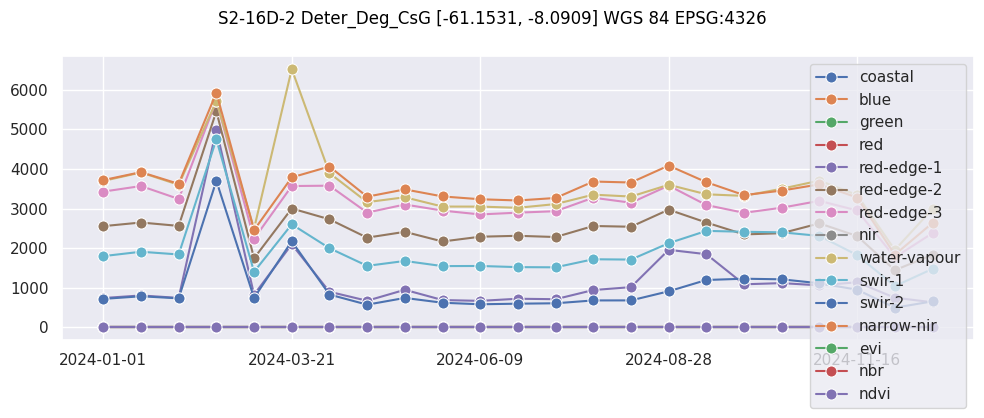

In [11]:
plot_ts(df_sits_pixels, 34)

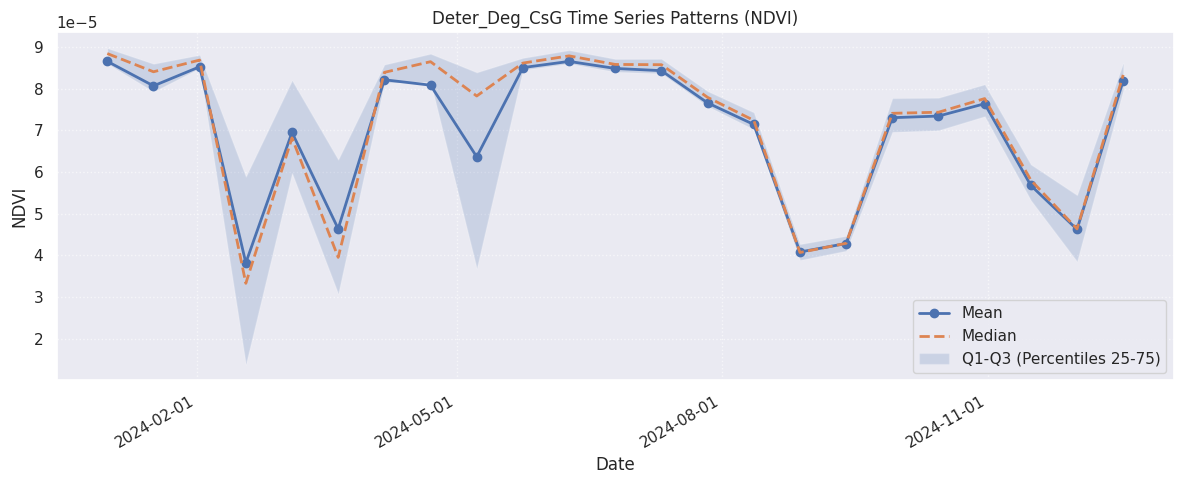

In [13]:
plot_patterns(df_sits_pixels, "ndvi")